# Cricket Player Detection and Tracking

Detects and tracks cricket players from elevated fixed-camera match footage (England U19 Women vs Australia). Uses YOLOv8 with sliced inference to handle the very small player sizes typical of wide-angle ground-level or elevated shots.

**Video format:** .MTS (AVCHD) stored in Google Drive

**Requirements:**
- R1: Detect players from fixed-camera match footage
- R2: Define ROI limited to the playing field
- R3: Use YOLO as starting model
- R4: Handle small/distant players using sliced inference
- R5: Tune confidence thresholds (60% down to 50%)
- R6: Annotation and retraining pipeline

## 1. Setup and Installation

In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)
print("Python:", sys.version)

Running in Colab: True
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
import subprocess

packages = [
    "ultralytics>=8.3.0",
    "opencv-python-headless==4.9.0.80",
    # "numpy==1.24.4",
    # "pandas",
    # "matplotlib",
    # "seaborn",
    "supervision==0.19.0",
    "tqdm",
    "pyyaml",
    "lap",
]

for pkg in packages:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        print(f"  ok: {pkg}")
    except:
        print(f"  skipped: {pkg}")

# sahi separately
try:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "sahi==0.11.18", "-q"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )
    SAHI_AVAILABLE = True
    print("  ok: sahi")
except:
    SAHI_AVAILABLE = False
    print("  sahi not available - will use manual slicing")

print("\nDone")

  ok: ultralytics>=8.3.0
  ok: opencv-python-headless==4.9.0.80
  ok: supervision==0.19.0
  ok: tqdm
  ok: pyyaml
  ok: lap
  ok: sahi

Done


In [4]:
!pip install pandas

In [3]:
import os
import cv2
import time
import json
import math
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from collections import deque
from tqdm import tqdm

warnings.filterwarnings("ignore")

if IN_COLAB:
    matplotlib.use("module://matplotlib_inline.backend_inline")

try:
    from ultralytics import YOLO
    YOLO_OK = True
    print("YOLO loaded")
except ImportError:
    YOLO_OK = False
    print("YOLO not available")

try:
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    SAHI_AVAILABLE = True
    print("SAHI loaded")
except ImportError:
    SAHI_AVAILABLE = False
    print("SAHI not available - using manual slicing")

print("OpenCV:", cv2.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO loaded
SAHI loaded
OpenCV: 4.9.0


## 2. Mount Google Drive and Load Video

 video is an .MTS file (AVCHD format from a camcorder) stored in Google Drive. OpenCV can read .MTS files directly.  

**Important:** Update the VIDEO_PATH below to match the exact location in your Drive.

In [4]:
# mount google drive
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted")
else:
    print("Not in Colab - set VIDEO_PATH manually below")


VIDEO_PATH = "/content/drive/MyDrive/England U19 Women Game 1 vs Australia Part 5.MTS"

# check if file exists
if os.path.exists(VIDEO_PATH):
    size_mb = os.path.getsize(VIDEO_PATH) / (1024 * 1024)
    print(f"Video found: {VIDEO_PATH}")
    print(f"File size: {size_mb:.1f} MB")
else:
    print(f"Video NOT found at: {VIDEO_PATH}")
    print()
    print("Please update VIDEO_PATH above to the correct path.")
    print("To find it, run this in a new cell:")
    print('  !find /content/drive/MyDrive -name "*.MTS" -type f')
    print()
    print("Or browse your Drive files in the left panel of Colab.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted
Video found: /content/drive/MyDrive/England U19 Women Game 1 vs Australia Part 5.MTS
File size: 2484.1 MB


In [ ]:
# if you are not sure where the file is, uncomment and run this to search
# !find /content/drive/MyDrive -name "*.MTS" -type f 2>/dev/null
# !find /content/drive/MyDrive -name "*England*" -type f 2>/dev/null

## 3. Configuration

Parameters tuned for your specific footage:
- Elevated camera, full oval ground visible
- Players are very small (roughly 20-50 pixels tall)
- Two teams: yellow (Australia) and red/dark (England)
- Pavilion and trees at top of frame - need to exclude from ROI
- .MTS video is typically 1920x1080 at 25fps or 50i

In [5]:
OUTPUT_DIR = "output"
DATASET_DIR = "dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)

# -- video processing --
# start with a short clip first, then set to None for full video
MAX_FRAMES = 200                    # ~8 seconds at 25fps. set None for full video
FRAME_SKIP = 1                      # process every frame

# -- YOLO detection --
YOLO_MODEL = "yolov8x.pt"          # largest model for best accuracy
YOLO_CONFIDENCE = 0.45              # tuned for this footage
YOLO_IOU = 0.45
INPUT_SIZE = 1280                   # high resolution for small players
TARGET_CLASSES = [0]                # person class

# -- slicing for small players --
# your players are ~20-50px tall so slicing is essential
SLICE_WIDTH = 640
SLICE_HEIGHT = 640
SLICE_OVERLAP = 0.25

# -- confidence sweep values --
CONFIDENCE_LEVELS = [0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30, 0.25]

# -- player size filters (tuned for your elevated camera angle) --
# players are very small in this footage
MIN_HEIGHT = 12
MAX_HEIGHT = 120
MIN_WIDTH = 6
MAX_WIDTH = 80
ASPECT_RATIO_MIN = 0.15
ASPECT_RATIO_MAX = 1.5

# -- expected on-field players --
EXPECTED_PLAYERS = 13               # 11 fielders + 2 batsmen

print("Configuration loaded")
print(f"Max frames: {MAX_FRAMES}")
print(f"Confidence: {YOLO_CONFIDENCE}")
print(f"Player height range: {MIN_HEIGHT}-{MAX_HEIGHT}px")

Configuration loaded
Max frames: 200
Confidence: 0.45
Player height range: 12-120px


## 4. Load Video Frames

Read frames from the .MTS video file. MTS is an AVCHD format that OpenCV reads via ffmpeg (pre-installed in Colab).

In [6]:
def load_video(path, max_frames=200, skip=1):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        print(f"ERROR: cannot open {path}")
        print("Possible fixes:")
        print("  1. Check the file path is correct")
        print("  2. Try converting: !ffmpeg -i input.MTS -c copy output.mp4")
        return None, {}

    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    info = {"fps": fps, "total_frames": total, "width": w, "height": h}
    print(f"Video: {w}x{h}, {fps:.1f}fps, {total} frames ({total/max(fps,1):.1f}s)")

    if max_frames:
        print(f"Loading first {max_frames} frames (start with short clip)")

    frames = []
    num = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if num % skip == 0:
            frames.append((num, frame))
            if max_frames and len(frames) >= max_frames:
                break
        num += 1
    cap.release()

    print(f"Loaded {len(frames)} frames")
    return frames, info


# load video
video_frames = None
video_info = {}

if os.path.exists(VIDEO_PATH):
    video_frames, video_info = load_video(VIDEO_PATH, MAX_FRAMES, FRAME_SKIP)

# if MTS failed, try converting to mp4 first
if video_frames is None and os.path.exists(VIDEO_PATH):
    print("\nTrying to convert .MTS to .mp4 using ffmpeg...")
    mp4_path = os.path.join(OUTPUT_DIR, "converted.mp4")
    convert_cmd = f'ffmpeg -i "{VIDEO_PATH}" -c:v libx264 -preset fast -crf 22 -frames:v {MAX_FRAMES or 500} "{mp4_path}" -y -loglevel error'
    os.system(convert_cmd)
    if os.path.exists(mp4_path):
        video_frames, video_info = load_video(mp4_path, MAX_FRAMES, FRAME_SKIP)

if video_frames is None:
    print("\nCould not load video. Generating synthetic frames for testing.")
    # synthetic fallback
    np.random.seed(42)
    frames = []
    for i in range(MAX_FRAMES or 60):
        h, w = 1080, 1920
        field = np.full((h, w, 3), (40, 130, 40), np.uint8)
        noise = np.random.randint(0, 15, field.shape, np.uint8)
        field = cv2.add(field, noise)
        cx, cy = w // 2, h // 2
        cv2.rectangle(field, (cx-40, cy-120), (cx+40, cy+120), (170, 150, 110), -1)
        for p in range(np.random.randint(11, 16)):
            px = np.random.randint(200, w-200)
            py = np.random.randint(250, h-100)
            pw, ph = np.random.randint(12, 25), np.random.randint(30, 55)
            col = (50, 220, 220) if p < 11 else (50, 50, 200)
            cv2.rectangle(field, (px, py), (px+pw, py+ph), col, -1)
        field[:200, :] = np.random.randint(60, 140, (200, w, 3), np.uint8)
        frames.append((i, field))
    video_frames = frames
    video_info = {"fps": 25, "width": 1920, "height": 1080}
    print(f"Generated {len(frames)} synthetic frames")

Video: 1920x1080, 25.0fps, 40566 frames (1622.6s)
Loading first 200 frames (start with short clip)
Loaded 200 frames


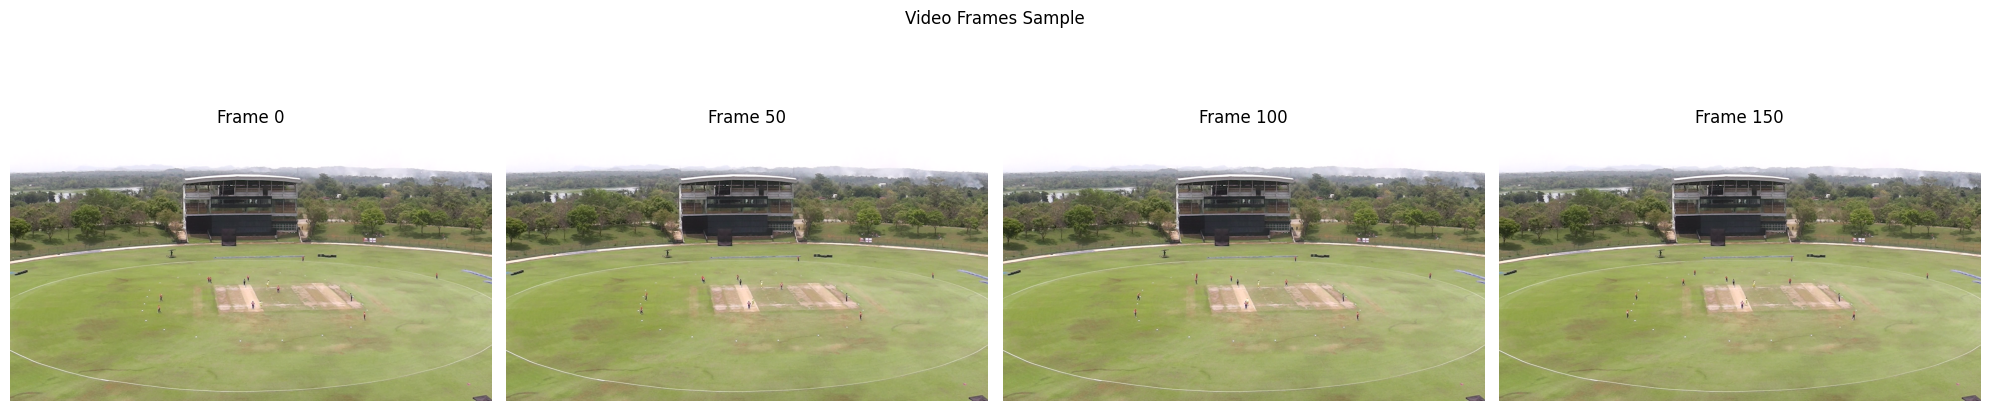

In [7]:
# show sample frames from the video
if video_frames:
    indices = [0, len(video_frames)//4, len(video_frames)//2, 3*len(video_frames)//4]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, idx in zip(axes, indices):
        if idx < len(video_frames):
            fnum, frame = video_frames[idx]
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            ax.set_title(f"Frame {fnum}")
        ax.axis("off")
    plt.suptitle("Video Frames Sample")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "video_samples.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 5. Region of Interest (ROI) - R2

Looking at your video, the playing field occupies roughly the lower two-thirds of the frame. The top portion has the pavilion, trees, and sky which we need to exclude. The field boundary is roughly elliptical.

The ROI is shifted downward and made slightly wider to match your camera angle.

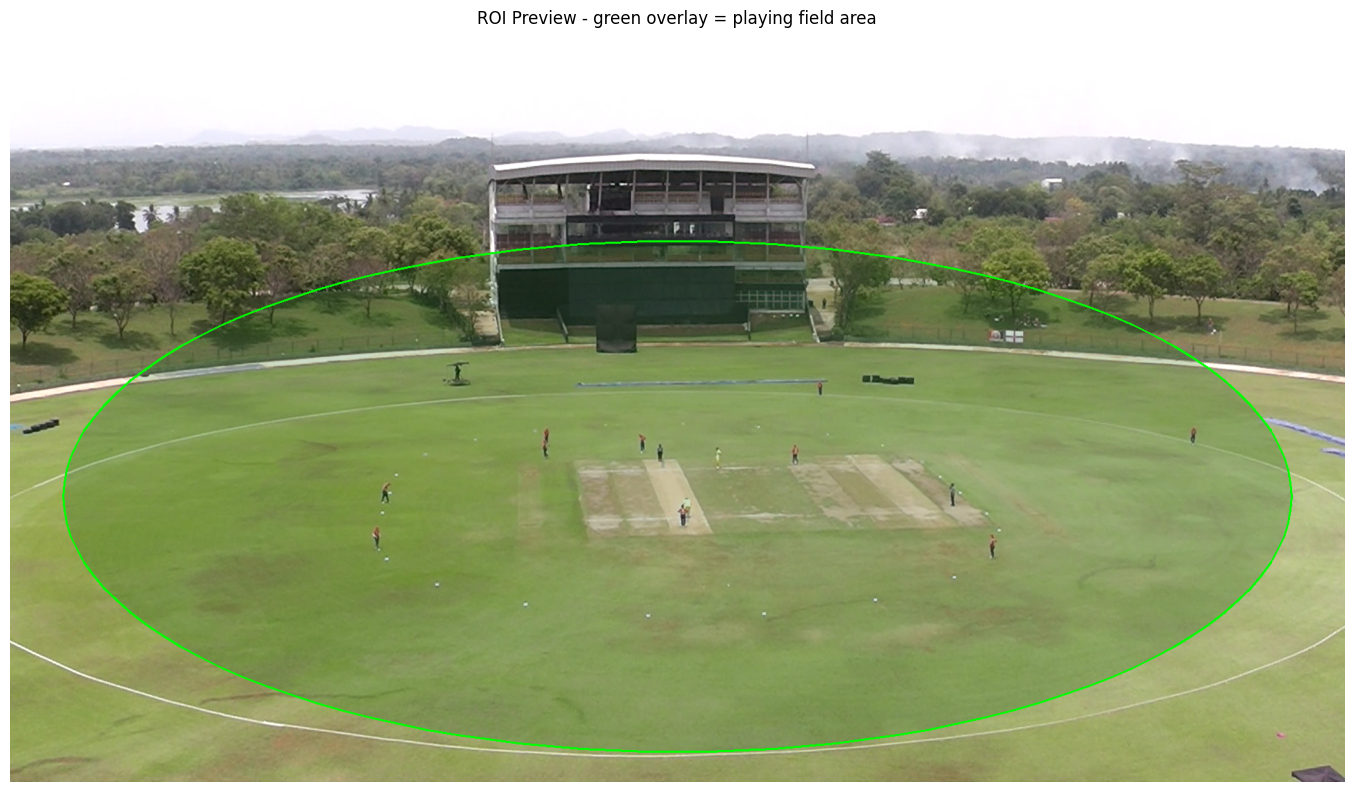

ROI saved to roi_polygon.json
Image size: 1920x1080
If the ROI does not fit your field, adjust cx, cy, rx, ry values above


In [8]:
def make_roi_for_this_video(width, height):
    # custom ROI for this elevated camera angle
    # the field is in the lower portion of frame, pavilion at top
    # shift the ellipse center down and make it wider than tall

    cx = width * 0.50           # horizontally centered
    cy = height * 0.62          # shifted down (field is in lower 2/3)
    rx = width * 0.46           # wide ellipse
    ry = height * 0.34          # shorter vertically (field is compressed from this angle)

    points = []
    for angle in range(0, 360, 3):
        rad = math.radians(angle)
        x = int(cx + rx * math.cos(rad))
        y = int(cy + ry * math.sin(rad))
        # clamp to image bounds
        x = max(0, min(width - 1, x))
        y = max(0, min(height - 1, y))
        points.append([x, y])

    return np.array(points, dtype=np.int32)


def is_inside_roi(cx, cy, roi_poly):
    result = cv2.pointPolygonTest(
        roi_poly.astype(np.float32), (float(cx), float(cy)), False
    )
    return result >= 0


def draw_roi(frame, roi_poly):
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_poly], (0, 80, 0))
    out = cv2.addWeighted(overlay, 0.2, frame, 0.8, 0)
    cv2.polylines(out, [roi_poly], True, (0, 255, 0), 2)
    return out


# create ROI
sample_frame = video_frames[0][1]
img_h, img_w = sample_frame.shape[:2]
roi_polygon = make_roi_for_this_video(img_w, img_h)

# save
with open("roi_polygon.json", "w") as f:
    json.dump({"polygon": roi_polygon.tolist(), "size": [img_w, img_h]}, f)

# preview on a sample frame from middle of video
mid_frame = video_frames[len(video_frames) // 2][1]
preview = draw_roi(mid_frame.copy(), roi_polygon)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title("ROI Preview - green overlay = playing field area")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roi_preview.png"), dpi=150, bbox_inches="tight")
plt.show()
print("ROI saved to roi_polygon.json")
print(f"Image size: {img_w}x{img_h}")
print("If the ROI does not fit your field, adjust cx, cy, rx, ry values above")

## 6. Detection Functions

Two detection modes:
1. Standard YOLO - runs on the full 1920x1080 frame
2. Sliced detection - splits into 640x640 tiles with 25% overlap, runs YOLO on each tile. This is essential because your players are only 20-50 pixels tall.

In [9]:
def detect_standard(frame, model, confidence=0.45, imgsz=1280):
    results = model(frame, conf=confidence, iou=YOLO_IOU,
                    imgsz=imgsz, classes=TARGET_CLASSES, verbose=False)
    detections = []
    for r in results:
        if r.boxes is None:
            continue
        for i in range(len(r.boxes)):
            box = r.boxes.xyxy[i].cpu().numpy()
            conf_val = float(r.boxes.conf[i])
            detections.append({
                "x1": int(box[0]), "y1": int(box[1]),
                "x2": int(box[2]), "y2": int(box[3]),
                "confidence": conf_val,
            })
    return detections


def detect_sliced_sahi(frame, model, confidence=0.45, slice_w=640, slice_h=640, overlap=0.25):
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    det_model = AutoDetectionModel.from_pretrained(
        model_type="yolov8", model=model,
        confidence_threshold=confidence, device=device,
    )
    result = get_sliced_prediction(
        frame, det_model,
        slice_height=slice_h, slice_width=slice_w,
        overlap_height_ratio=overlap, overlap_width_ratio=overlap,
    )
    detections = []
    for pred in result.object_prediction_list:
        if pred.category.id == 0:
            b = pred.bbox
            detections.append({
                "x1": int(b.minx), "y1": int(b.miny),
                "x2": int(b.maxx), "y2": int(b.maxy),
                "confidence": pred.score.value,
            })
    return detections


def detect_sliced_manual(frame, model, confidence=0.45, slice_w=640, slice_h=640, overlap=0.25):
    # manual tiling fallback
    h_img, w_img = frame.shape[:2]
    step_x = int(slice_w * (1 - overlap))
    step_y = int(slice_h * (1 - overlap))
    all_dets = []

    for y_start in range(0, h_img, step_y):
        for x_start in range(0, w_img, step_x):
            x_end = min(x_start + slice_w, w_img)
            y_end = min(y_start + slice_h, h_img)
            if (x_end - x_start) < 100 or (y_end - y_start) < 100:
                continue
            tile = frame[y_start:y_end, x_start:x_end]
            tile_dets = detect_standard(tile, model, confidence, 640)
            for d in tile_dets:
                d["x1"] += x_start
                d["y1"] += y_start
                d["x2"] += x_start
                d["y2"] += y_start
                all_dets.append(d)

    # remove duplicates from overlapping tiles
    all_dets.sort(key=lambda d: d["confidence"], reverse=True)
    kept = []
    for d in all_dets:
        cx = (d["x1"] + d["x2"]) / 2
        cy = (d["y1"] + d["y2"]) / 2
        dup = False
        for k in kept:
            kcx = (k["x1"] + k["x2"]) / 2
            kcy = (k["y1"] + k["y2"]) / 2
            if math.sqrt((cx - kcx)**2 + (cy - kcy)**2) < 25:
                dup = True
                break
        if not dup:
            kept.append(d)
    return kept


def detect_sliced(frame, model, confidence=0.45, slice_w=640, slice_h=640, overlap=0.25):
    if SAHI_AVAILABLE:
        return detect_sliced_sahi(frame, model, confidence, slice_w, slice_h, overlap)
    else:
        return detect_sliced_manual(frame, model, confidence, slice_w, slice_h, overlap)


def filter_detections(detections, roi_poly):
    filtered = []
    for d in detections:
        w = d["x2"] - d["x1"]
        h = d["y2"] - d["y1"]
        if h < MIN_HEIGHT or h > MAX_HEIGHT:
            continue
        if w < MIN_WIDTH or w > MAX_WIDTH:
            continue
        ratio = w / max(h, 1)
        if ratio < ASPECT_RATIO_MIN or ratio > ASPECT_RATIO_MAX:
            continue
        cx = (d["x1"] + d["x2"]) / 2
        cy = (d["y1"] + d["y2"]) / 2
        if not is_inside_roi(cx, cy, roi_poly):
            continue
        filtered.append(d)
    return filtered


print("Detection functions ready")
print(f"Slicing: {'SAHI' if SAHI_AVAILABLE else 'manual tiling'}")

Detection functions ready
Slicing: SAHI


## 7. Experiment A - Sliced vs Standard YOLO (R3, R4)

Compare standard full-image detection vs sliced detection. With your camera angle, players are so small that standard YOLO will miss most of them.

In [10]:
if YOLO_OK:
    model = YOLO(YOLO_MODEL)
    print(f"Loaded: {YOLO_MODEL}")

    # pick 10 evenly spaced frames
    test_indices = np.linspace(0, len(video_frames)-1, min(10, len(video_frames)), dtype=int)
    test_frames = [video_frames[i] for i in test_indices]

    std_counts = []
    sl_counts = []
    t_std = []
    t_sl = []

    for fnum, frame in test_frames:
        t0 = time.time()
        d_std = detect_standard(frame, model, YOLO_CONFIDENCE, INPUT_SIZE)
        d_std = filter_detections(d_std, roi_polygon)
        t_std.append(time.time() - t0)
        std_counts.append(len(d_std))

        t0 = time.time()
        d_sl = detect_sliced(frame, model, YOLO_CONFIDENCE, SLICE_WIDTH, SLICE_HEIGHT, SLICE_OVERLAP)
        d_sl = filter_detections(d_sl, roi_polygon)
        t_sl.append(time.time() - t0)
        sl_counts.append(len(d_sl))

        print(f"  Frame {fnum}: Standard={len(d_std)}, Sliced={len(d_sl)}")

    exp_a = pd.DataFrame({
        "frame": [f for f, _ in test_frames],
        "standard": std_counts, "sliced": sl_counts,
        "time_std": t_std, "time_sl": t_sl,
    })
    exp_a.to_csv(os.path.join(OUTPUT_DIR, "experiment_a_comparison.csv"), index=False)
    print(f"\nAvg Standard: {np.mean(std_counts):.1f}, Avg Sliced: {np.mean(sl_counts):.1f}")
    print(f"Improvement: +{np.mean(sl_counts) - np.mean(std_counts):.1f} players")

Loaded: yolov8x.pt
Performing prediction on 8 slices.
  Frame 0: Standard=14, Sliced=14
Performing prediction on 8 slices.
  Frame 22: Standard=11, Sliced=12
Performing prediction on 8 slices.
  Frame 44: Standard=12, Sliced=12
Performing prediction on 8 slices.
  Frame 66: Standard=11, Sliced=11
Performing prediction on 8 slices.
  Frame 88: Standard=10, Sliced=10
Performing prediction on 8 slices.
  Frame 110: Standard=10, Sliced=11
Performing prediction on 8 slices.
  Frame 132: Standard=13, Sliced=14
Performing prediction on 8 slices.
  Frame 154: Standard=13, Sliced=13
Performing prediction on 8 slices.
  Frame 176: Standard=14, Sliced=14
Performing prediction on 8 slices.
  Frame 199: Standard=13, Sliced=14

Avg Standard: 12.1, Avg Sliced: 12.5
Improvement: +0.4 players


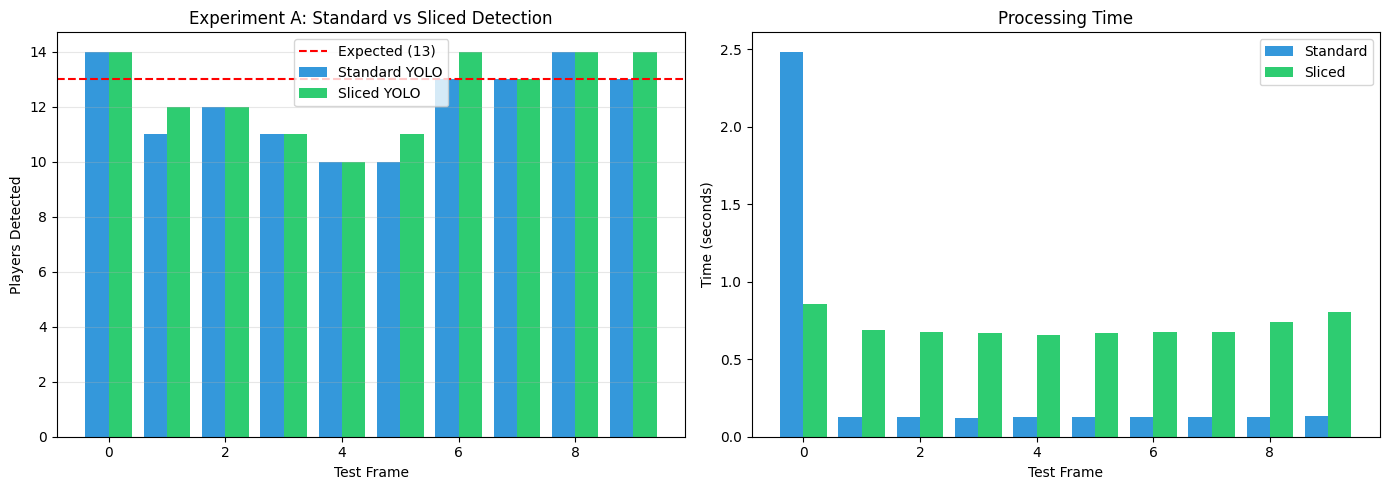

In [11]:
if YOLO_OK:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = range(len(test_frames))

    ax1.bar([i-0.2 for i in x], std_counts, 0.4, label="Standard YOLO", color="#3498db")
    ax1.bar([i+0.2 for i in x], sl_counts, 0.4, label="Sliced YOLO", color="#2ecc71")
    ax1.axhline(y=EXPECTED_PLAYERS, color="red", linestyle="--", label=f"Expected ({EXPECTED_PLAYERS})")
    ax1.set_xlabel("Test Frame")
    ax1.set_ylabel("Players Detected")
    ax1.set_title("Experiment A: Standard vs Sliced Detection")
    ax1.legend()
    ax1.grid(axis="y", alpha=0.3)

    ax2.bar([i-0.2 for i in x], t_std, 0.4, label="Standard", color="#3498db")
    ax2.bar([i+0.2 for i in x], t_sl, 0.4, label="Sliced", color="#2ecc71")
    ax2.set_xlabel("Test Frame")
    ax2.set_ylabel("Time (seconds)")
    ax2.set_title("Processing Time")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "experiment_a_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 8. Experiment B - Confidence Threshold Sweep (R5)

Performing prediction on 8 slices.
  Conf 0.60: 10 players
Performing prediction on 8 slices.
  Conf 0.55: 10 players
Performing prediction on 8 slices.
  Conf 0.50: 11 players
Performing prediction on 8 slices.
  Conf 0.45: 12 players
Performing prediction on 8 slices.
  Conf 0.40: 12 players
Performing prediction on 8 slices.
  Conf 0.35: 12 players
Performing prediction on 8 slices.
  Conf 0.30: 12 players
Performing prediction on 8 slices.
  Conf 0.25: 12 players


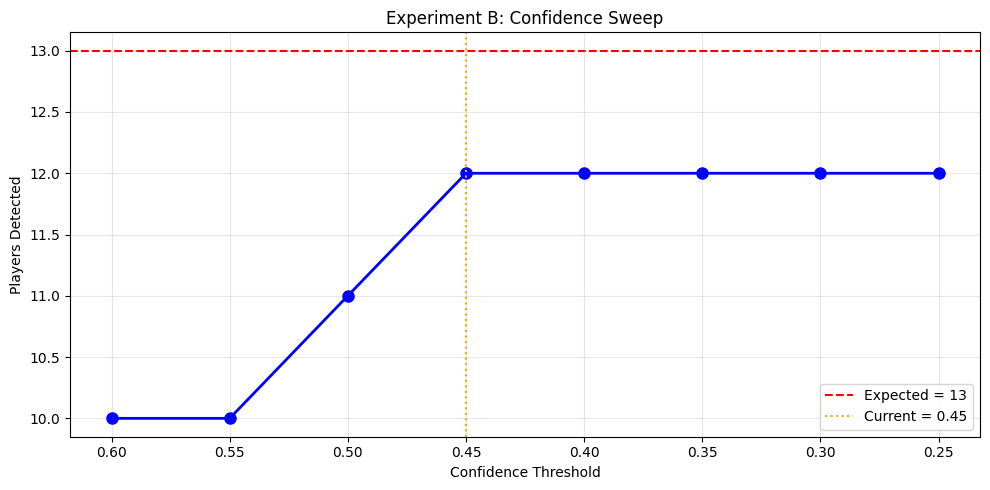

In [12]:
if YOLO_OK:
    mid_frame = video_frames[len(video_frames)//2][1]
    sweep = []

    for conf in CONFIDENCE_LEVELS:
        dets = detect_sliced(mid_frame, model, conf, SLICE_WIDTH, SLICE_HEIGHT, SLICE_OVERLAP)
        dets = filter_detections(dets, roi_polygon)
        sweep.append({"confidence": conf, "count": len(dets)})
        print(f"  Conf {conf:.2f}: {len(dets)} players")

    exp_b = pd.DataFrame(sweep)
    exp_b.to_csv(os.path.join(OUTPUT_DIR, "experiment_b_sweep.csv"), index=False)

    plt.figure(figsize=(10, 5))
    plt.plot(exp_b["confidence"], exp_b["count"], "bo-", linewidth=2, markersize=8)
    plt.axhline(y=EXPECTED_PLAYERS, color="red", linestyle="--", label=f"Expected = {EXPECTED_PLAYERS}")
    plt.axvline(x=YOLO_CONFIDENCE, color="orange", linestyle=":", label=f"Current = {YOLO_CONFIDENCE}")
    plt.xlabel("Confidence Threshold")
    plt.ylabel("Players Detected")
    plt.title("Experiment B: Confidence Sweep")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.gca().invert_xaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "experiment_b_sweep.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 9. Experiment C - Consistency Check (R3)

Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing predictio

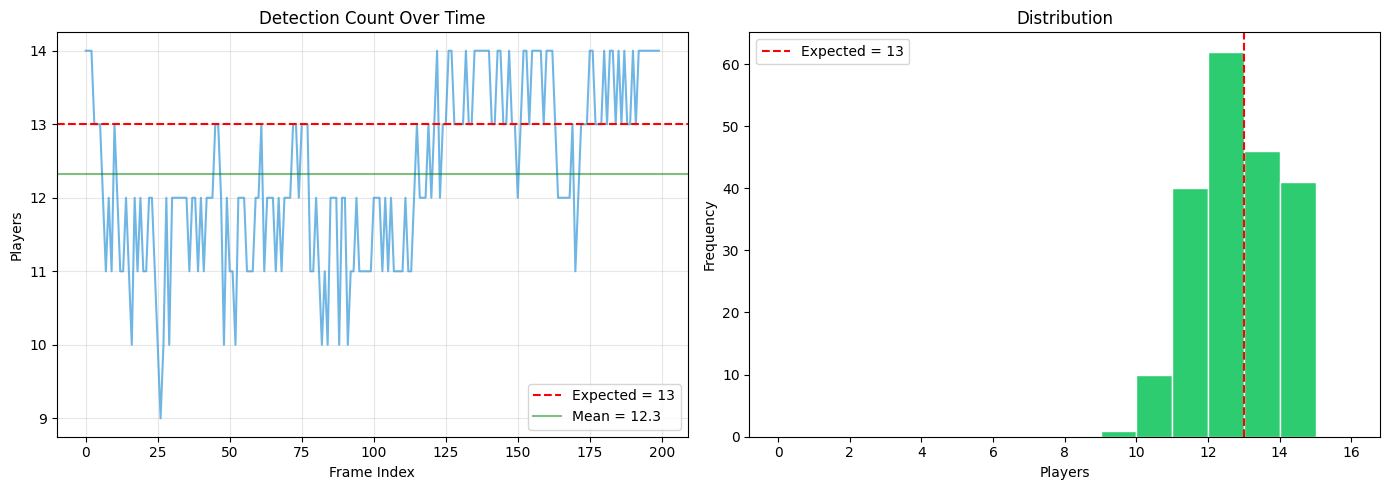

In [13]:
if YOLO_OK:
    counts = []
    for fnum, frame in video_frames:
        dets = detect_sliced(frame, model, YOLO_CONFIDENCE, SLICE_WIDTH, SLICE_HEIGHT, SLICE_OVERLAP)
        dets = filter_detections(dets, roi_polygon)
        counts.append(len(dets))

    exp_c = pd.DataFrame({"frame": [f for f, _ in video_frames], "count": counts})
    exp_c.to_csv(os.path.join(OUTPUT_DIR, "experiment_c_consistency.csv"), index=False)

    print(f"Avg: {np.mean(counts):.1f}, Std: {np.std(counts):.1f}, Range: {min(counts)}-{max(counts)}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(range(len(counts)), counts, color="#3498db", alpha=0.7)
    ax1.axhline(y=EXPECTED_PLAYERS, color="red", linestyle="--", label=f"Expected = {EXPECTED_PLAYERS}")
    ax1.axhline(y=np.mean(counts), color="green", linestyle="-", alpha=0.5, label=f"Mean = {np.mean(counts):.1f}")
    ax1.set_xlabel("Frame Index")
    ax1.set_ylabel("Players")
    ax1.set_title("Detection Count Over Time")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.hist(counts, bins=range(0, max(counts)+3), color="#2ecc71", edgecolor="white")
    ax2.axvline(x=EXPECTED_PLAYERS, color="red", linestyle="--", label=f"Expected = {EXPECTED_PLAYERS}")
    ax2.set_xlabel("Players")
    ax2.set_ylabel("Frequency")
    ax2.set_title("Distribution")
    ax2.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "experiment_c_consistency.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 10. Full Pipeline - Detect, Track, Export (R1-R5)

In [14]:
if YOLO_OK:
    all_results = []
    annotated_dir = os.path.join(OUTPUT_DIR, "annotated")
    os.makedirs(annotated_dir, exist_ok=True)

    # also write an output video
    h_out, w_out = video_frames[0][1].shape[:2]
    vid_out_path = os.path.join(OUTPUT_DIR, "tracked_output.mp4")
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps_out = video_info.get("fps", 25)
    writer = cv2.VideoWriter(vid_out_path, fourcc, fps_out, (w_out, h_out))

    for idx, (fnum, frame) in enumerate(video_frames):
        dets = detect_sliced(frame, model, YOLO_CONFIDENCE,
                              SLICE_WIDTH, SLICE_HEIGHT, SLICE_OVERLAP)
        dets = filter_detections(dets, roi_polygon)

        ann = draw_roi(frame.copy(), roi_polygon)

        for i, d in enumerate(dets):
            # green box with player number
            cv2.rectangle(ann, (d["x1"], d["y1"]), (d["x2"], d["y2"]), (0, 255, 0), 2)
            label = f"P{i+1} {d['confidence']:.2f}"
            cv2.putText(ann, label, (d["x1"], d["y1"] - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 255, 0), 1)

            cx = (d["x1"] + d["x2"]) / 2
            cy = (d["y1"] + d["y2"]) / 2
            all_results.append({
                "frame": fnum, "player_id": i + 1,
                "x1": d["x1"], "y1": d["y1"], "x2": d["x2"], "y2": d["y2"],
                "center_x": round(cx, 1), "center_y": round(cy, 1),
                "width": d["x2"] - d["x1"], "height": d["y2"] - d["y1"],
                "confidence": round(d["confidence"], 3),
            })

        # info bar
        cv2.rectangle(ann, (5, 5), (350, 35), (0, 0, 0), -1)
        info = f"Frame {fnum} | {len(dets)} players | conf={YOLO_CONFIDENCE}"
        cv2.putText(ann, info, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        writer.write(ann)

        # save a few annotated frames as images
        if idx % 20 == 0:
            cv2.imwrite(os.path.join(annotated_dir, f"frame_{fnum:06d}.jpg"), ann)

        if (idx + 1) % 25 == 0:
            print(f"  [{idx+1}/{len(video_frames)}] Frame {fnum}: {len(dets)} players")

    writer.release()

    df = pd.DataFrame(all_results)
    csv_path = os.path.join(OUTPUT_DIR, "detections.csv")
    df.to_csv(csv_path, index=False)

    print(f"\nTotal: {len(all_results)} detections across {len(video_frames)} frames")
    print(f"Video: {vid_out_path}")
    print(f"CSV: {csv_path}")
    print()
    print(df.head(10).to_string(index=False))

Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
  [25/200] Frame 24: 11 players
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction o

## 11. Analysis

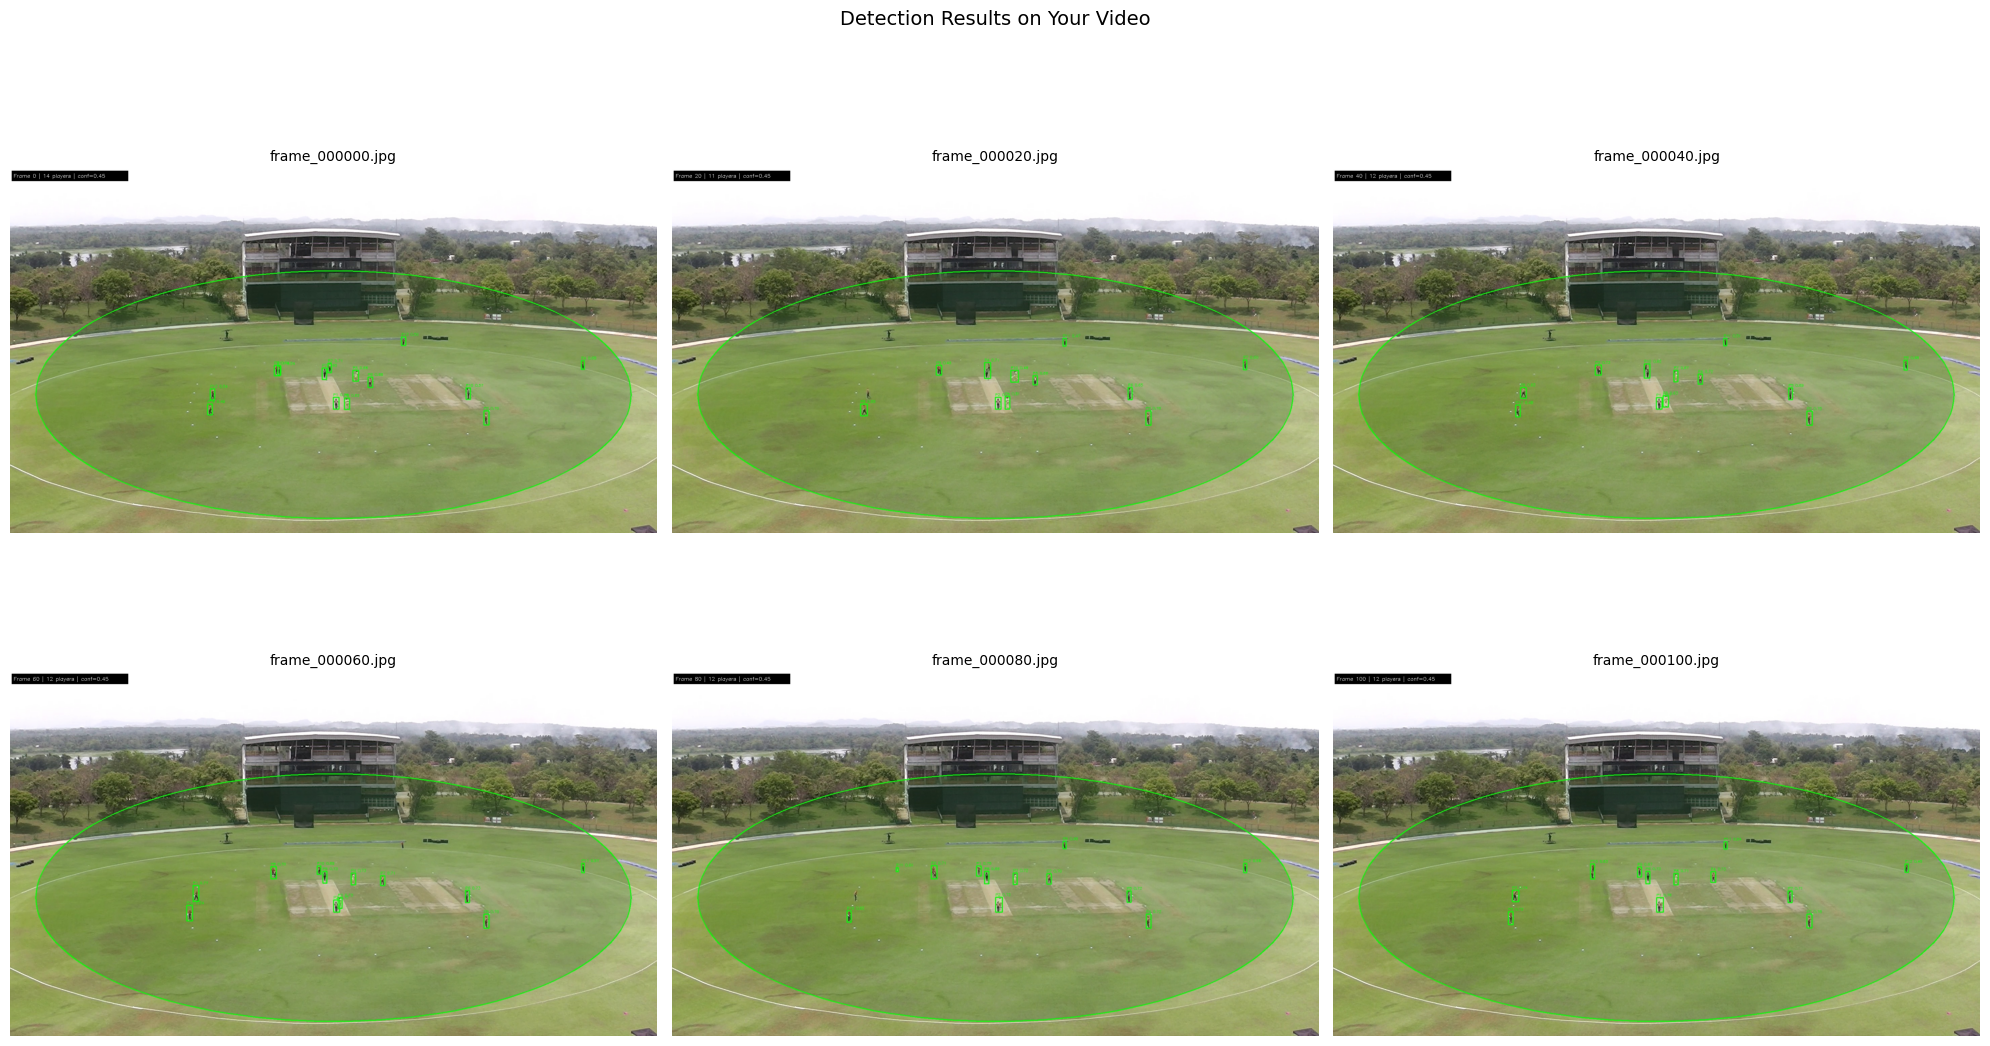

In [15]:
if YOLO_OK and len(all_results) > 0:
    # show annotated frames
    ann_files = sorted([f for f in os.listdir(annotated_dir) if f.endswith(".jpg")])
    show_n = min(6, len(ann_files))
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    for i in range(show_n):
        img = cv2.imread(os.path.join(annotated_dir, ann_files[i]))
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(ann_files[i], fontsize=10)
        axes[i].axis("off")
    for i in range(show_n, 6):
        axes[i].axis("off")
    plt.suptitle("Detection Results on Your Video", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "annotated_samples.png"), dpi=150, bbox_inches="tight")
    plt.show()

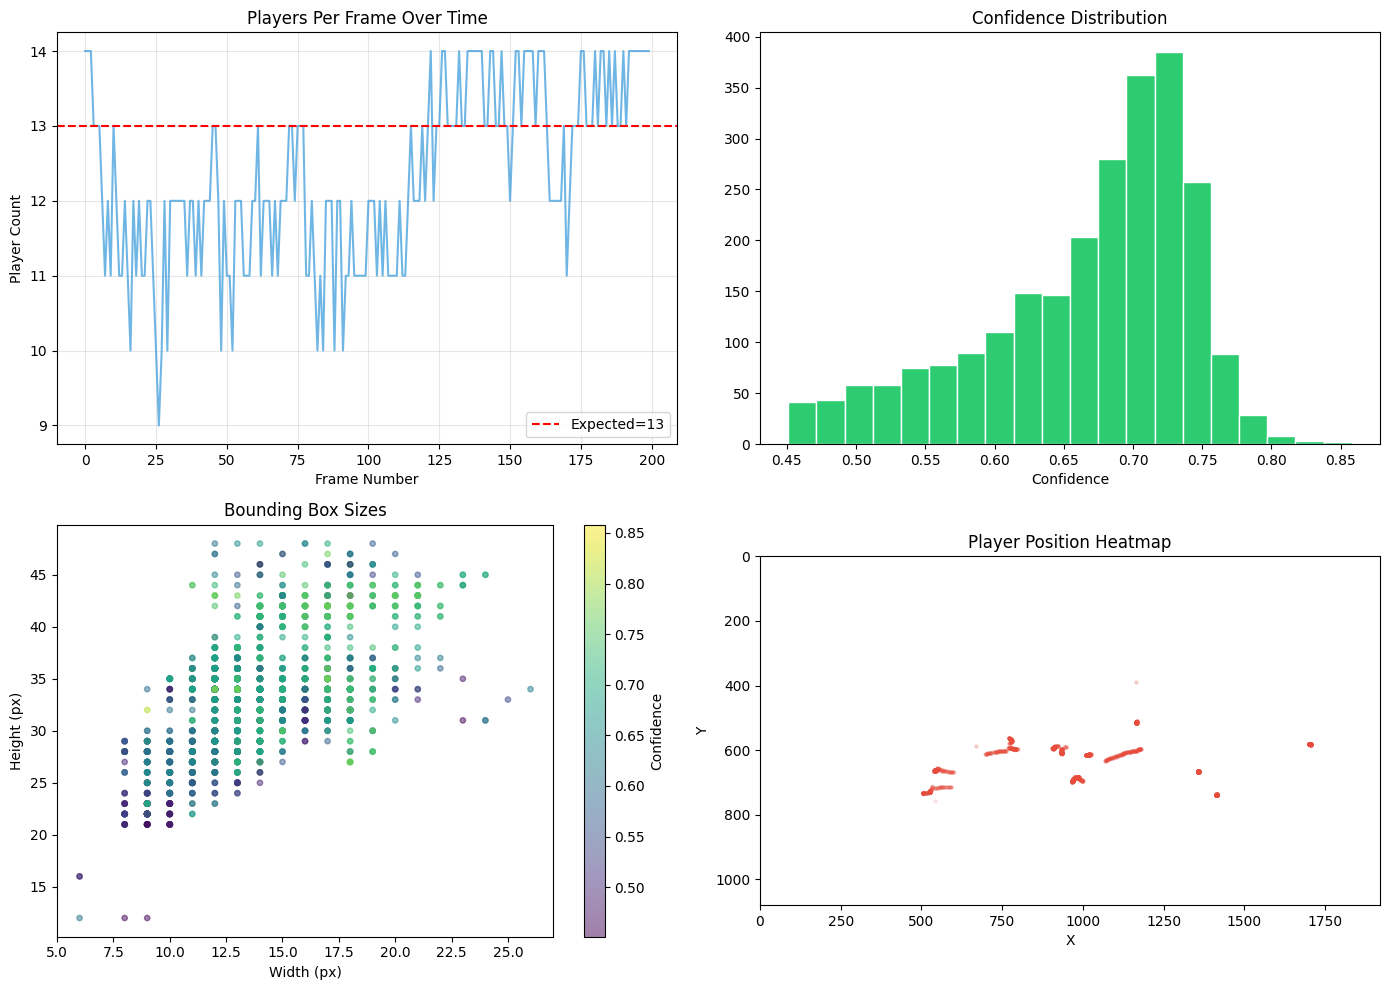

In [16]:
if YOLO_OK and len(df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    per_frame = df.groupby("frame").size()
    axes[0, 0].plot(per_frame.index, per_frame.values, color="#3498db", alpha=0.7)
    axes[0, 0].axhline(y=EXPECTED_PLAYERS, color="red", linestyle="--", label=f"Expected={EXPECTED_PLAYERS}")
    axes[0, 0].set_xlabel("Frame Number")
    axes[0, 0].set_ylabel("Player Count")
    axes[0, 0].set_title("Players Per Frame Over Time")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].hist(df["confidence"], bins=20, color="#2ecc71", edgecolor="white")
    axes[0, 1].set_xlabel("Confidence")
    axes[0, 1].set_title("Confidence Distribution")

    sc = axes[1, 0].scatter(df["width"], df["height"],
                             c=df["confidence"], cmap="viridis", alpha=0.5, s=15)
    axes[1, 0].set_xlabel("Width (px)")
    axes[1, 0].set_ylabel("Height (px)")
    axes[1, 0].set_title("Bounding Box Sizes")
    plt.colorbar(sc, ax=axes[1, 0], label="Confidence")

    # position heatmap on field
    axes[1, 1].scatter(df["center_x"], df["center_y"], alpha=0.1, s=5, c="#e74c3c")
    axes[1, 1].set_xlabel("X")
    axes[1, 1].set_ylabel("Y")
    axes[1, 1].set_title("Player Position Heatmap")
    axes[1, 1].invert_yaxis()
    axes[1, 1].set_xlim(0, img_w)
    axes[1, 1].set_ylim(img_h, 0)
    axes[1, 1].set_aspect("equal")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "analysis_plots.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 12. Annotation and Retraining Pipeline (R6)

In [17]:
if YOLO_OK:
    labels_dir = os.path.join(DATASET_DIR, "labels")
    images_dir = os.path.join(DATASET_DIR, "images")
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(images_dir, exist_ok=True)

    # extract frames every 30th for annotation
    frame_step = max(1, len(video_frames) // 100)  # aim for ~100 frames
    annotation_frames = video_frames[::frame_step]

    for fnum, frame in annotation_frames:
        fname = f"frame_{fnum:06d}.jpg"
        cv2.imwrite(os.path.join(images_dir, fname), frame)

        h, w = frame.shape[:2]
        dets = detect_standard(frame, model, confidence=0.15, imgsz=INPUT_SIZE)
        dets = filter_detections(dets, roi_polygon)

        lbl_name = f"frame_{fnum:06d}.txt"
        with open(os.path.join(labels_dir, lbl_name), "w") as f:
            for d in dets:
                bx = ((d["x1"] + d["x2"]) / 2) / w
                by = ((d["y1"] + d["y2"]) / 2) / h
                bw = (d["x2"] - d["x1"]) / w
                bh = (d["y2"] - d["y1"]) / h
                f.write(f"0 {bx:.6f} {by:.6f} {bw:.6f} {bh:.6f}\n")

    with open(os.path.join(DATASET_DIR, "classes.txt"), "w") as f:
        f.write("player\n")

    print(f"Extracted {len(annotation_frames)} frames for annotation")
    print(f"Images: {images_dir}")
    print(f"Pre-labels: {labels_dir}")
    print("Next: correct labels in LabelImg/CVAT/Roboflow, then train")

Extracted 100 frames for annotation
Images: dataset/images
Pre-labels: dataset/labels
Next: correct labels in LabelImg/CVAT/Roboflow, then train


In [18]:
if YOLO_OK:
    # split into train/val/test
    random.seed(42)
    all_imgs = sorted(os.listdir(images_dir))
    random.shuffle(all_imgs)
    n = len(all_imgs)
    splits = {
        "train": all_imgs[:int(n*0.7)],
        "val": all_imgs[int(n*0.7):int(n*0.9)],
        "test": all_imgs[int(n*0.9):],
    }
    for name, files in splits.items():
        d_img = os.path.join(DATASET_DIR, name, "images")
        d_lbl = os.path.join(DATASET_DIR, name, "labels")
        os.makedirs(d_img, exist_ok=True)
        os.makedirs(d_lbl, exist_ok=True)
        for fn in files:
            shutil.copy2(os.path.join(images_dir, fn), os.path.join(d_img, fn))
            lbl = os.path.join(labels_dir, os.path.splitext(fn)[0] + ".txt")
            if os.path.exists(lbl):
                shutil.copy2(lbl, os.path.join(d_lbl, os.path.splitext(fn)[0] + ".txt"))
        print(f"  {name}: {len(files)} images")

    import yaml
    data_yaml = {"path": os.path.abspath(DATASET_DIR), "train": "train/images",
                 "val": "val/images", "test": "test/images", "nc": 1, "names": ["player"]}
    with open(os.path.join(DATASET_DIR, "data.yaml"), "w") as f:
        yaml.dump(data_yaml, f, default_flow_style=False)
    print(f"data.yaml saved")

  train: 70 images
  val: 20 images
  test: 10 images
data.yaml saved


In [ ]:
# Fine-tuning (uncomment to run - needs GPU)
#
# model_ft = YOLO("yolov8m.pt")
# results = model_ft.train(
#     data=os.path.join(DATASET_DIR, "data.yaml"),
#     epochs=100, batch=8, imgsz=1280, patience=20,
#     optimizer="AdamW", lr0=0.001, cos_lr=True,
#     mosaic=1.0, mixup=0.1, copy_paste=0.1,
#     degrees=0.0,    # no rotation - fixed camera
#     box=7.5,
#     project="runs/detect", name="cricket_player_v1",
# )

## 13. Evaluation

In [19]:
def compute_iou(a, b):
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0

def evaluate(pred_csv, gt_csv, iou_thresh=0.5):
    preds = pd.read_csv(pred_csv)
    gt = pd.read_csv(gt_csv)
    tp, fp, fn = 0, 0, 0
    for img in gt["frame"].unique():
        gb = gt[gt["frame"]==img][["x1","y1","x2","y2"]].values.tolist()
        pb = preds[preds["frame"]==img][["x1","y1","x2","y2"]].values.tolist()
        matched = set()
        for p in pb:
            best_iou, best_j = 0, -1
            for j, g in enumerate(gb):
                v = compute_iou(p, g)
                if v > best_iou: best_iou, best_j = v, j
            if best_iou >= iou_thresh and best_j not in matched:
                tp += 1; matched.add(best_j)
            else: fp += 1
        fn += len(gb) - len(matched)
    prec = tp / max(tp+fp, 1)
    rec = tp / max(tp+fn, 1)
    f1 = 2*prec*rec / max(prec+rec, 1e-6)
    print(f"Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

# uncomment when ground truth ready:
# evaluate("output/detections.csv", "ground_truth.csv")
print("Evaluation ready")

Evaluation ready


## 14. Download Results

Run this cell to download the output files from Colab to your computer.

In [20]:
if IN_COLAB:
    from google.colab import files
    import zipfile

    zip_path = "cricket_detection_results.zip"
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, filenames in os.walk(OUTPUT_DIR):
            for fn in filenames:
                filepath = os.path.join(root, fn)
                arcname = os.path.relpath(filepath, ".")
                zf.write(filepath, arcname)

    print(f"Zipped results: {zip_path}")
    files.download(zip_path)
else:
    print("Results are in the output/ folder")

Zipped results: cricket_detection_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Summary

| Output | Description |
|---|---|
| output/tracked_output.mp4 | Annotated video with bounding boxes |
| output/detections.csv | Frame-by-frame player coordinates |
| output/experiment_a_comparison.csv/png | Standard vs Sliced comparison |
| output/experiment_b_sweep.csv/png | Confidence threshold sweep |
| output/experiment_c_consistency.csv/png | Detection consistency |
| output/annotated/ | Sample annotated frames |
| output/analysis_plots.png | Analysis charts |
| dataset/data.yaml | Training configuration |

| Requirement | Section |
|---|---|
| R1: Detect players from match footage | Sections 6, 10 |
| R2: ROI limited to the field | Section 5 |
| R3: YOLO as starting model | Sections 6, 7 |
| R4: Small player handling (slicing) | Sections 6, 7 |
| R5: Confidence threshold tuning | Section 8 |
| R6: Annotation and retraining | Section 12 |